# Analysis of our SABRE vs Qiskit's LightSABRE implementation 

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import json

In [ ]:
with open('light_sabre.json', 'r') as f:
    light_sabre_data = json.load(f)
with open('our_sabre.json', 'r') as f:
    our_sabre_data = json.load(f)

data = light_sabre_data + our_sabre_data

implementations = []
init_times = []
mapping_times = []
routing_times = []
total_times = []

for result in data:
    impl = result.get('impl', 'unknown')
    config_name = result.get('config_name', '')
    
    if impl == "light_sabre":
        label = f"LightSABRE\n{config_name}"
    else:
        label = f"Our SABRE\n{config_name}"
    
    implementations.append(label)
    init_times.append(result["init_time"])
    mapping_times.append(result["mapping_time"])
    routing_times.append(result["routing_time"])
    total_times.append(result["total_time"])

## Execution Time Analysis between our SABRE and Average LightSABRE

> LightSABRE is written in rust and our SABRE is written in python

In [10]:
light_sabre_mask = [impl == "light_sabre" for impl in [result.get('impl') for result in data]]
our_sabre_mask = [not x for x in light_sabre_mask]

ls_init = [t for t, m in zip(init_times, light_sabre_mask) if m]
ls_mapping = [t for t, m in zip(mapping_times, light_sabre_mask) if m]
ls_routing = [t for t, m in zip(routing_times, light_sabre_mask) if m]
ls_total = [t for t, m in zip(total_times, light_sabre_mask) if m]

our_init = [t for t, m in zip(init_times, our_sabre_mask) if m]
our_mapping = [t for t, m in zip(mapping_times, our_sabre_mask) if m]
our_routing = [t for t, m in zip(routing_times, our_sabre_mask) if m]
our_total = [t for t, m in zip(total_times, our_sabre_mask) if m]

/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_74628/346489960.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=['LightSABRE', 'Our SABRE'],


✓ Visualization saved as 'time_decomposition.png'

TIME DECOMPOSITION ANALYSIS

Dataset Size:
  Total results:      1440
  LightSABRE results: 1080
  Our SABRE results:  360

Component       LightSABRE (avg)     Our SABRE (avg)      Slowdown       
----------------------------------------------------------------------
Init                   0.000275s             0.0003s             1x
Mapping                0.011624s            21.8675s          1881x
Routing                0.001560s             2.0709s          1327x
Total                  0.013459s            23.9387s          1779x

Percentage Breakdown:
  LightSABRE - Init: 2.0%, Mapping: 86.4%, Routing: 11.6%
  Our SABRE  - Init: 0.0%, Mapping: 91.3%, Routing: 8.7%

Bottleneck Analysis:
  Our SABRE spends 91.3% of time in Mapping phase
  Mapping is the primary bottleneck (1881x slower)

Statistical Summary:
  LightSABRE - Median: 0.012486s, Std: 0.006835s
  Our SABRE  - Median: 10.5258s, Std: 33.8697s


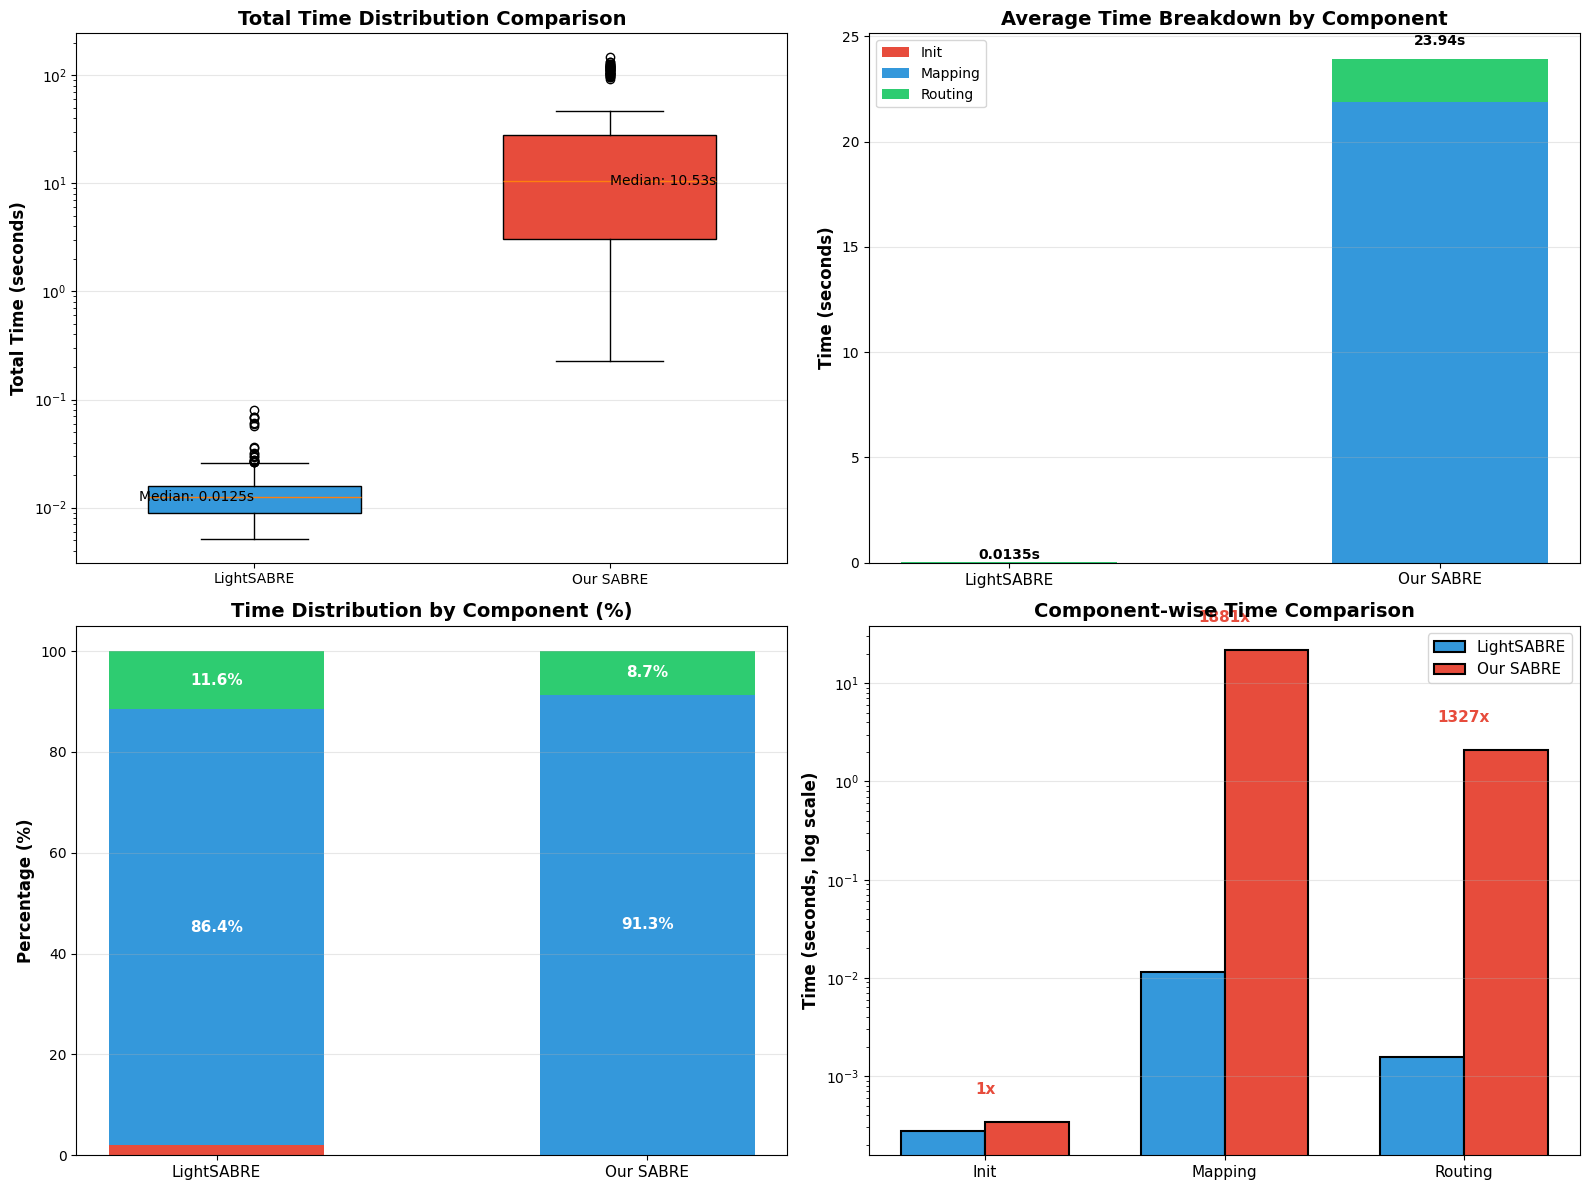

In [11]:
# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot comparison - Total Time Distribution
ax1 = axes[0, 0]
box_data = [ls_total, our_total]
bp = ax1.boxplot(box_data, labels=['LightSABRE', 'Our SABRE'], 
                  patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')

ax1.set_ylabel('Total Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Total Time Distribution Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_yscale('log')

# Add statistics text
ls_median = np.median(ls_total)
our_median = np.median(our_total)
ax1.text(1, ls_median, f'Median: {ls_median:.4f}s', ha='right', va='center', fontsize=10)
ax1.text(2, our_median, f'Median: {our_median:.2f}s', ha='left', va='center', fontsize=10)

# 2. Stacked bar chart - Average time breakdown
ax2 = axes[0, 1]
components = ['Init', 'Mapping', 'Routing']
ls_avg = [np.mean(ls_init), np.mean(ls_mapping), np.mean(ls_routing)]
our_avg = [np.mean(our_init), np.mean(our_mapping), np.mean(our_routing)]

x = np.arange(2)
width = 0.5

# LightSABRE stacked bar
ax2.bar(0, ls_avg[0], width, label='Init', color='#e74c3c')
ax2.bar(0, ls_avg[1], width, bottom=ls_avg[0], label='Mapping', color='#3498db')
ax2.bar(0, ls_avg[2], width, bottom=ls_avg[0]+ls_avg[1], label='Routing', color='#2ecc71')

# Our SABRE stacked bar
ax2.bar(1, our_avg[0], width, color='#e74c3c')
ax2.bar(1, our_avg[1], width, bottom=our_avg[0], color='#3498db')
ax2.bar(1, our_avg[2], width, bottom=our_avg[0]+our_avg[1], color='#2ecc71')

ax2.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Average Time Breakdown by Component', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['LightSABRE', 'Our SABRE'], fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add total time labels
ls_total_avg = sum(ls_avg)
our_total_avg = sum(our_avg)
ax2.text(0, ls_total_avg * 1.02, f'{ls_total_avg:.4f}s', ha='center', va='bottom', 
         fontsize=10, fontweight='bold')
ax2.text(1, our_total_avg * 1.02, f'{our_total_avg:.2f}s', ha='center', va='bottom',
         fontsize=10, fontweight='bold')

# 3. Percentage breakdown comparison
ax3 = axes[1, 0]
ls_total_avg = sum(ls_avg)
our_total_avg = sum(our_avg)

ls_pct = [val/ls_total_avg*100 for val in ls_avg]
our_pct = [val/our_total_avg*100 for val in our_avg]

# Stacked percentage bars
ax3.bar(0, ls_pct[0], width, color='#e74c3c')
ax3.bar(0, ls_pct[1], width, bottom=ls_pct[0], color='#3498db')
ax3.bar(0, ls_pct[2], width, bottom=ls_pct[0]+ls_pct[1], color='#2ecc71')

ax3.bar(1, our_pct[0], width, color='#e74c3c')
ax3.bar(1, our_pct[1], width, bottom=our_pct[0], color='#3498db')
ax3.bar(1, our_pct[2], width, bottom=our_pct[0]+our_pct[1], color='#2ecc71')

ax3.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax3.set_title('Time Distribution by Component (%)', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['LightSABRE', 'Our SABRE'], fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (impl_pct, x_pos) in enumerate([(ls_pct, 0), (our_pct, 1)]):
    y_positions = [impl_pct[0]/2, impl_pct[0]+impl_pct[1]/2, impl_pct[0]+impl_pct[1]+impl_pct[2]/2]
    labels = [f'{impl_pct[0]:.1f}%', f'{impl_pct[1]:.1f}%', f'{impl_pct[2]:.1f}%']
    
    for y_pos, label in zip(y_positions, labels):
        if float(label.replace('%', '')) > 3:  # Only show if slice is visible
            ax3.text(x_pos, y_pos, label, ha='center', va='center', 
                    fontsize=11, color='white', fontweight='bold')

# 4. Component-wise comparison (log scale)
ax4 = axes[1, 1]
x_comp = np.arange(len(components))
width_comp = 0.35

bars1 = ax4.bar(x_comp - width_comp/2, ls_avg, width_comp, 
                label='LightSABRE', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax4.bar(x_comp + width_comp/2, our_avg, width_comp,
                label='Our SABRE', color='#e74c3c', edgecolor='black', linewidth=1.5)

ax4.set_ylabel('Time (seconds, log scale)', fontsize=12, fontweight='bold')
ax4.set_title('Component-wise Time Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x_comp)
ax4.set_xticklabels(components, fontsize=11)
ax4.legend(fontsize=11)
ax4.grid(axis='y', alpha=0.3)
ax4.set_yscale('log')

# Add slowdown labels
for i, (light, our) in enumerate(zip(ls_avg, our_avg)):
    slowdown = our / light
    ax4.text(i, our * 1.8, f'{slowdown:.0f}x', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.savefig('time_decomposition.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'time_decomposition.png'")

# Print detailed statistics
print("\n" + "="*70)
print("TIME DECOMPOSITION ANALYSIS")
print("="*70)
print(f"\nDataset Size:")
print(f"  Total results:      {len(implementations)}")
print(f"  LightSABRE results: {len(ls_total)}")
print(f"  Our SABRE results:  {len(our_total)}")

print(f"\n{'Component':<15} {'LightSABRE (avg)':<20} {'Our SABRE (avg)':<20} {'Slowdown':<15}")
print("-" * 70)
for i, comp in enumerate(components):
    print(f"{comp:<15} {ls_avg[i]:>15.6f}s    {our_avg[i]:>15.4f}s    {our_avg[i]/ls_avg[i]:>10.0f}x")

print(f"{'Total':<15} {ls_total_avg:>15.6f}s    {our_total_avg:>15.4f}s    {our_total_avg/ls_total_avg:>10.0f}x")

print(f"\nPercentage Breakdown:")
print(f"  LightSABRE - Init: {ls_pct[0]:.1f}%, Mapping: {ls_pct[1]:.1f}%, Routing: {ls_pct[2]:.1f}%")
print(f"  Our SABRE  - Init: {our_pct[0]:.1f}%, Mapping: {our_pct[1]:.1f}%, Routing: {our_pct[2]:.1f}%")

print(f"\nBottleneck Analysis:")
print(f"  Our SABRE spends {our_pct[1]:.1f}% of time in Mapping phase")
print(f"  Mapping is the primary bottleneck ({our_avg[1]/ls_avg[1]:.0f}x slower)")

print(f"\nStatistical Summary:")
print(f"  LightSABRE - Median: {np.median(ls_total):.6f}s, Std: {np.std(ls_total):.6f}s")
print(f"  Our SABRE  - Median: {np.median(our_total):.4f}s, Std: {np.std(our_total):.4f}s")

print("="*70)

## Execution Time Analysis between our SABRE and each heuristics in LightSABRE

In [13]:
basic_data = []
lookahead_data = []
decay_data = []

for result in light_sabre_data:
    heuristic = result["config"]["swap_heuristic"]
    if heuristic == "basic":
        basic_data.append(result)
    elif heuristic == "lookahead":
        lookahead_data.append(result)
    elif heuristic == "decay":
        decay_data.append(result)

def extract_times(data):
    init = [d["init_time"] for d in data]
    mapping = [d["mapping_time"] for d in data]
    routing = [d["routing_time"] for d in data]
    total = [d["total_time"] for d in data]
    return init, mapping, routing, total

basic_init, basic_mapping, basic_routing, basic_total = extract_times(basic_data)
lookahead_init, lookahead_mapping, lookahead_routing, lookahead_total = extract_times(lookahead_data)
decay_init, decay_mapping, decay_routing, decay_total = extract_times(decay_data)
our_init, our_mapping, our_routing, our_total = extract_times(our_sabre_data)

basic_avg = [np.mean(basic_init), np.mean(basic_mapping), np.mean(basic_routing)]
lookahead_avg = [np.mean(lookahead_init), np.mean(lookahead_mapping), np.mean(lookahead_routing)]
decay_avg = [np.mean(decay_init), np.mean(decay_mapping), np.mean(decay_routing)]
our_avg = [np.mean(our_init), np.mean(our_mapping), np.mean(our_routing)]

basic_total_avg = sum(basic_avg)
lookahead_total_avg = sum(lookahead_avg)
decay_total_avg = sum(decay_avg)
our_total_avg = sum(our_avg)

/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_74628/3431136681.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=['LS: Basic', 'LS: Lookahead', 'LS: Decay', 'Our SABRE'],


✓ Visualization saved as 'full_comparison.png'

COMPLETE HEURISTICS COMPARISON (LightSABRE vs Our SABRE)

Dataset Sizes:
  LS Basic:     360 results
  LS Lookahead: 360 results
  LS Decay:     360 results
  Our SABRE:    360 results

Component       LS Basic        LS Lookahead    LS Decay        Our SABRE      
------------------------------------------------------------------------------------------
Init              0.000279s     0.000273s     0.000273s       0.0003s
Mapping           0.011051s     0.011882s     0.011940s      21.8675s
Routing           0.001994s     0.001360s     0.001327s       2.0709s
Total             0.013324s     0.013515s     0.013539s      23.9387s

Percentage Breakdown:
  LS Basic:     Init:   2.1%, Mapping:  82.9%, Routing:  15.0%
  LS Lookahead: Init:   2.0%, Mapping:  87.9%, Routing:  10.1%
  LS Decay:     Init:   2.0%, Mapping:  88.2%, Routing:   9.8%
  Our SABRE:    Init:   0.0%, Mapping:  91.3%, Routing:   8.7%

Relative Performance:
  Our SABRE vs LS

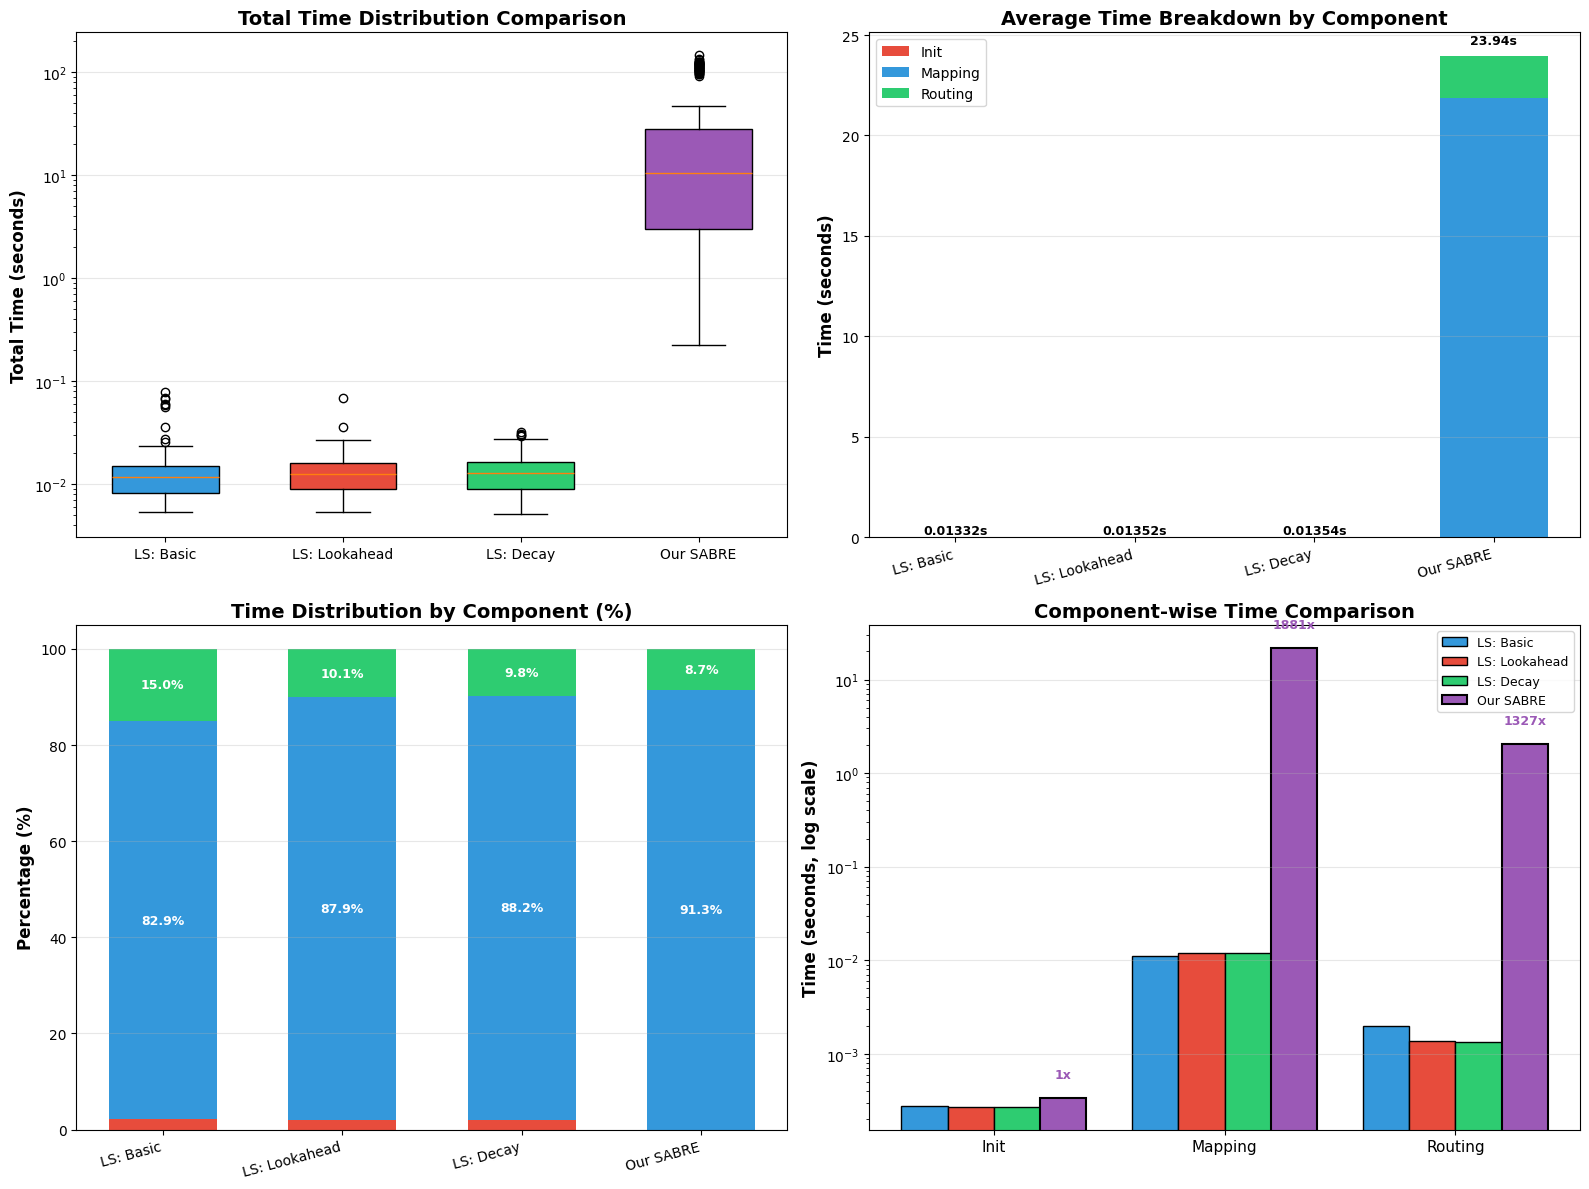

In [14]:
# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot - Total time distribution
ax1 = axes[0, 0]
box_data = [basic_total, lookahead_total, decay_total, our_total]
bp = ax1.boxplot(box_data, labels=['LS: Basic', 'LS: Lookahead', 'LS: Decay', 'Our SABRE'], 
                  patch_artist=True, widths=0.6)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax1.set_ylabel('Total Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Total Time Distribution Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_yscale('log')

# Add median labels
medians = [np.median(d) for d in box_data]
for i, (median, color) in enumerate(zip(medians, colors), 1):
    ax1.text(i, median, f'{median:.4f}s', ha='center', va='bottom', 
             fontsize=8, fontweight='bold', color=color)

# 2. Stacked bar chart - Average time breakdown
ax2 = axes[0, 1]
components = ['Init', 'Mapping', 'Routing']
x = np.arange(4)
width = 0.6

# Stacked bars for each implementation
all_avgs = [basic_avg, lookahead_avg, decay_avg, our_avg]
labels = ['LS: Basic', 'LS: Lookahead', 'LS: Decay', 'Our SABRE']

for i, (avg, label) in enumerate(zip(all_avgs, labels)):
    if i == 0:
        ax2.bar(i, avg[0], width, label='Init', color='#e74c3c')
        ax2.bar(i, avg[1], width, bottom=avg[0], label='Mapping', color='#3498db')
        ax2.bar(i, avg[2], width, bottom=avg[0]+avg[1], label='Routing', color='#2ecc71')
    else:
        ax2.bar(i, avg[0], width, color='#e74c3c')
        ax2.bar(i, avg[1], width, bottom=avg[0], color='#3498db')
        ax2.bar(i, avg[2], width, bottom=avg[0]+avg[1], color='#2ecc71')

ax2.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Average Time Breakdown by Component', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10, rotation=15, ha='right')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add total time labels
all_totals = [basic_total_avg, lookahead_total_avg, decay_total_avg, our_total_avg]
for i, total in enumerate(all_totals):
    format_str = f'{total:.5f}s' if total < 1 else f'{total:.2f}s'
    ax2.text(i, total * 1.02, format_str, ha='center', va='bottom', 
             fontsize=9, fontweight='bold')

# 3. Percentage breakdown
ax3 = axes[1, 0]
basic_pct = [val/basic_total_avg*100 for val in basic_avg]
lookahead_pct = [val/lookahead_total_avg*100 for val in lookahead_avg]
decay_pct = [val/decay_total_avg*100 for val in decay_avg]
our_pct = [val/our_total_avg*100 for val in our_avg]

all_pcts = [basic_pct, lookahead_pct, decay_pct, our_pct]

# Stacked percentage bars
for i, pct in enumerate(all_pcts):
    ax3.bar(i, pct[0], width, color='#e74c3c')
    ax3.bar(i, pct[1], width, bottom=pct[0], color='#3498db')
    ax3.bar(i, pct[2], width, bottom=pct[0]+pct[1], color='#2ecc71')

ax3.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax3.set_title('Time Distribution by Component (%)', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=10, rotation=15, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, pct in enumerate(all_pcts):
    y_positions = [pct[0]/2, pct[0]+pct[1]/2, pct[0]+pct[1]+pct[2]/2]
    pct_labels = [f'{pct[0]:.1f}%', f'{pct[1]:.1f}%', f'{pct[2]:.1f}%']
    
    for y_pos, label in zip(y_positions, pct_labels):
        if float(label.replace('%', '')) > 3:
            ax3.text(i, y_pos, label, ha='center', va='center', 
                    fontsize=9, color='white', fontweight='bold')

# 4. Component-wise comparison (log scale)
ax4 = axes[1, 1]
x_comp = np.arange(len(components))
width_comp = 0.2

bars1 = ax4.bar(x_comp - 1.5*width_comp, basic_avg, width_comp, 
                label='LS: Basic', color='#3498db', edgecolor='black', linewidth=1)
bars2 = ax4.bar(x_comp - 0.5*width_comp, lookahead_avg, width_comp,
                label='LS: Lookahead', color='#e74c3c', edgecolor='black', linewidth=1)
bars3 = ax4.bar(x_comp + 0.5*width_comp, decay_avg, width_comp,
                label='LS: Decay', color='#2ecc71', edgecolor='black', linewidth=1)
bars4 = ax4.bar(x_comp + 1.5*width_comp, our_avg, width_comp,
                label='Our SABRE', color='#9b59b6', edgecolor='black', linewidth=1.5)

ax4.set_ylabel('Time (seconds, log scale)', fontsize=12, fontweight='bold')
ax4.set_title('Component-wise Time Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x_comp)
ax4.set_xticklabels(components, fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_yscale('log')

# Add slowdown labels for Our SABRE vs LightSABRE average
ls_avg = [(basic_avg[i] + lookahead_avg[i] + decay_avg[i])/3 for i in range(3)]
for i, (ls, our) in enumerate(zip(ls_avg, our_avg)):
    slowdown = our / ls
    ax4.text(i + 1.5*width_comp, our * 1.5, f'{slowdown:.0f}x', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#9b59b6')

plt.tight_layout()
plt.savefig('full_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'full_comparison.png'")

# Print detailed statistics
print("\n" + "="*90)
print("COMPLETE HEURISTICS COMPARISON (LightSABRE vs Our SABRE)")
print("="*90)
print(f"\nDataset Sizes:")
print(f"  LS Basic:     {len(basic_data)} results")
print(f"  LS Lookahead: {len(lookahead_data)} results")
print(f"  LS Decay:     {len(decay_data)} results")
print(f"  Our SABRE:    {len(our_sabre_data)} results")

print(f"\n{'Component':<15} {'LS Basic':<15} {'LS Lookahead':<15} {'LS Decay':<15} {'Our SABRE':<15}")
print("-" * 90)
for i, comp in enumerate(components):
    print(f"{comp:<15} {basic_avg[i]:>10.6f}s   {lookahead_avg[i]:>10.6f}s   {decay_avg[i]:>10.6f}s   {our_avg[i]:>10.4f}s")

print(f"{'Total':<15} {basic_total_avg:>10.6f}s   {lookahead_total_avg:>10.6f}s   {decay_total_avg:>10.6f}s   {our_total_avg:>10.4f}s")

print(f"\nPercentage Breakdown:")
print(f"  LS Basic:     Init: {basic_pct[0]:>5.1f}%, Mapping: {basic_pct[1]:>5.1f}%, Routing: {basic_pct[2]:>5.1f}%")
print(f"  LS Lookahead: Init: {lookahead_pct[0]:>5.1f}%, Mapping: {lookahead_pct[1]:>5.1f}%, Routing: {lookahead_pct[2]:>5.1f}%")
print(f"  LS Decay:     Init: {decay_pct[0]:>5.1f}%, Mapping: {decay_pct[1]:>5.1f}%, Routing: {decay_pct[2]:>5.1f}%")
print(f"  Our SABRE:    Init: {our_pct[0]:>5.1f}%, Mapping: {our_pct[1]:>5.1f}%, Routing: {our_pct[2]:>5.1f}%")

# Calculate LightSABRE average
ls_total_avg = (basic_total_avg + lookahead_total_avg + decay_total_avg) / 3

print(f"\nRelative Performance:")
print(f"  Our SABRE vs LS Basic:     {our_total_avg/basic_total_avg:>6.0f}x slower")
print(f"  Our SABRE vs LS Lookahead: {our_total_avg/lookahead_total_avg:>6.0f}x slower")
print(f"  Our SABRE vs LS Decay:     {our_total_avg/decay_total_avg:>6.0f}x slower")
print(f"  Our SABRE vs LS Average:   {our_total_avg/ls_total_avg:>6.0f}x slower")

print(f"\nStatistical Summary:")
print(f"  LS Basic:     Median: {np.median(basic_total):.6f}s, Std: {np.std(basic_total):.6f}s")
print(f"  LS Lookahead: Median: {np.median(lookahead_total):.6f}s, Std: {np.std(lookahead_total):.6f}s")
print(f"  LS Decay:     Median: {np.median(decay_total):.6f}s, Std: {np.std(decay_total):.6f}s")
print(f"  Our SABRE:    Median: {np.median(our_total):.4f}s, Std: {np.std(our_total):.4f}s")

# Find fastest among LightSABRE
fastest_ls = min([(basic_total_avg, 'Basic'), 
                   (lookahead_total_avg, 'Lookahead'), 
                   (decay_total_avg, 'Decay')], key=lambda x: x[0])
print(f"\nFastest LightSABRE Heuristic: {fastest_ls[1]} ({fastest_ls[0]:.6f}s average)")

print(f"\nBottleneck Analysis (Our SABRE):")
print(f"  Mapping phase: {our_pct[1]:.1f}% of total time ({our_avg[1]:.2f}s)")
print(f"  Mapping is {our_avg[1]/ls_avg[1]:.0f}x slower than LightSABRE average")

print("="*90)

## Quality Analysis

In [ ]:
def extract_metrics(data):
    swaps = [d['routed_swaps'] for d in data]
    depth = [d['routed_depth'] for d in data]
    return swaps, depth

basic_swaps, basic_depth = extract_metrics(basic_data)
lookahead_swaps, lookahead_depth = extract_metrics(lookahead_data)
decay_swaps, decay_depth = extract_metrics(decay_data)
our_swaps, our_depth = extract_metrics(our_sabre_data)

def count_wins(our_swaps, our_depth, other_swaps, other_depth, name):
    wins_swaps = sum(1 for o, l in zip(our_swaps, other_swaps) if o < l)
    wins_depth = sum(1 for o, l in zip(our_depth, other_depth) if o < l)
    wins_both = sum(1 for os, od, ls, ld in zip(our_swaps, our_depth, other_swaps, other_depth) 
                    if os < ls and od < ld)
    ties = sum(1 for os, od, ls, ld in zip(our_swaps, our_depth, other_swaps, other_depth) 
               if os == ls and od == ld)
    
    total = len(our_swaps)
    return {
        'name': name,
        'wins_swaps': wins_swaps,
        'wins_depth': wins_depth,
        'wins_both': wins_both,
        'ties': ties,
        'total': total
    }

/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_74628/3162840472.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data_swaps, labels=['Basic', 'Look\nahead', 'Decay', 'Our\nSABRE'],
/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_74628/3162840472.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data_depth, labels=['Basic', 'Look\nahead', 'Decay', 'Our\nSABRE'],


✓ Quality comparison saved as 'quality_comparison.png'

QUALITY METRICS COMPARISON (Swaps & Depth Only)

Average Quality Metrics:
Implementation       Avg Swaps       Avg Depth       Median Swaps    Median Depth   
------------------------------------------------------------------------------------------
LS: Basic                 80.53         93.08            50            73
LS: Lookahead             48.64         82.17            31            64
LS: Decay                 48.28         81.77            30            65
Our SABRE                 63.98         94.42            42            72

Best Case Performance:
Implementation       Min Swaps       Min Depth      
------------------------------------------------------------------------------------------
LS: Basic                     1            13
LS: Lookahead                 3            15
LS: Decay                     2            13
Our SABRE                     2            14

Our SABRE vs. LightSABRE Average:
  Swap Coun

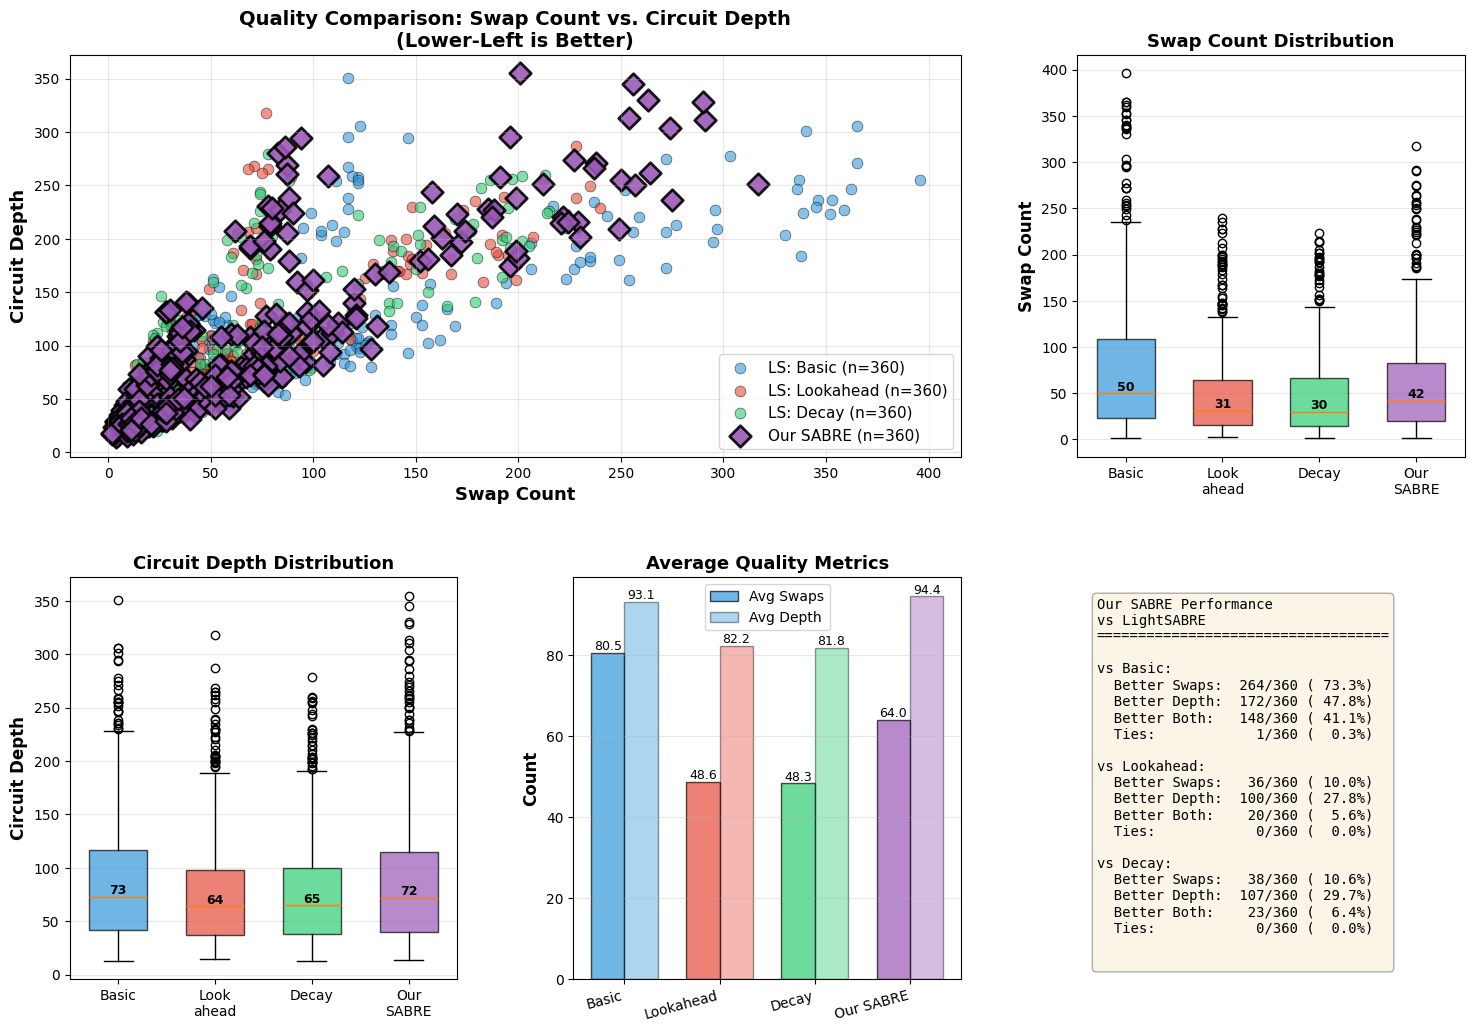

In [23]:
# Color scheme
colors = {
    'basic': '#3498db',
    'lookahead': '#e74c3c',
    'decay': '#2ecc71',
    'our': '#9b59b6'
}

# Create figure with 5 subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Main Scatter Plot (larger, spanning 2 columns)
ax1 = fig.add_subplot(gs[0, :2])

# Plot all points
ax1.scatter(basic_swaps, basic_depth, c=colors['basic'], s=60, alpha=0.6, 
            label=f'LS: Basic (n={len(basic_data)})', edgecolors='black', linewidth=0.5)
ax1.scatter(lookahead_swaps, lookahead_depth, c=colors['lookahead'], s=60, alpha=0.6, 
            label=f'LS: Lookahead (n={len(lookahead_data)})', edgecolors='black', linewidth=0.5)
ax1.scatter(decay_swaps, decay_depth, c=colors['decay'], s=60, alpha=0.6, 
            label=f'LS: Decay (n={len(decay_data)})', edgecolors='black', linewidth=0.5)
ax1.scatter(our_swaps, our_depth, c=colors['our'], s=120, alpha=0.9, 
            label=f'Our SABRE (n={len(our_sabre_data)})', edgecolors='black', linewidth=2, marker='D')

ax1.set_xlabel('Swap Count', fontsize=13, fontweight='bold')
ax1.set_ylabel('Circuit Depth', fontsize=13, fontweight='bold')
ax1.set_title('Quality Comparison: Swap Count vs. Circuit Depth\n(Lower-Left is Better)', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Swap Count Distribution (box plot)
ax2 = fig.add_subplot(gs[0, 2])

box_data_swaps = [basic_swaps, lookahead_swaps, decay_swaps, our_swaps]
bp = ax2.boxplot(box_data_swaps, labels=['Basic', 'Look\nahead', 'Decay', 'Our\nSABRE'], 
                  patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], [colors['basic'], colors['lookahead'], colors['decay'], colors['our']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('Swap Count', fontsize=12, fontweight='bold')
ax2.set_title('Swap Count Distribution', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add median values
medians_swaps = [np.median(d) for d in box_data_swaps]
for i, median in enumerate(medians_swaps, 1):
    ax2.text(i, median, f'{median:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Circuit Depth Distribution (box plot)
ax3 = fig.add_subplot(gs[1, 0])

box_data_depth = [basic_depth, lookahead_depth, decay_depth, our_depth]
bp = ax3.boxplot(box_data_depth, labels=['Basic', 'Look\nahead', 'Decay', 'Our\nSABRE'], 
                  patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], [colors['basic'], colors['lookahead'], colors['decay'], colors['our']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel('Circuit Depth', fontsize=12, fontweight='bold')
ax3.set_title('Circuit Depth Distribution', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add median values
medians_depth = [np.median(d) for d in box_data_depth]
for i, median in enumerate(medians_depth, 1):
    ax3.text(i, median, f'{median:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Average Quality Comparison (bar chart)
ax4 = fig.add_subplot(gs[1, 1])

implementations = ['Basic', 'Lookahead', 'Decay', 'Our SABRE']
avg_swaps = [np.mean(basic_swaps), np.mean(lookahead_swaps), np.mean(decay_swaps), np.mean(our_swaps)]
avg_depth = [np.mean(basic_depth), np.mean(lookahead_depth), np.mean(decay_depth), np.mean(our_depth)]

x = np.arange(len(implementations))
width = 0.35

bars1 = ax4.bar(x - width/2, avg_swaps, width, label='Avg Swaps', 
                color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'], alpha=0.7, edgecolor='black', linewidth=1)
bars2 = ax4.bar(x + width/2, avg_depth, width, label='Avg Depth', 
                color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'], alpha=0.4, edgecolor='black', linewidth=1)

ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('Average Quality Metrics', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(implementations, fontsize=10, rotation=15, ha='right')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# 5. Win/Loss Summary Table (text-based)
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

# Calculate wins for each LightSABRE variant
wins_vs_basic = count_wins(our_swaps, our_depth, basic_swaps, basic_depth, 'Basic')
wins_vs_lookahead = count_wins(our_swaps, our_depth, lookahead_swaps, lookahead_depth, 'Lookahead')
wins_vs_decay = count_wins(our_swaps, our_depth, decay_swaps, decay_depth, 'Decay')

# Create table text
table_text = "Our SABRE Performance\nvs LightSABRE\n" + "="*35 + "\n\n"

for wins in [wins_vs_basic, wins_vs_lookahead, wins_vs_decay]:
    table_text += f"vs {wins['name']}:\n"
    table_text += f"  Better Swaps:  {wins['wins_swaps']:3d}/{wins['total']} ({wins['wins_swaps']/wins['total']*100:5.1f}%)\n"
    table_text += f"  Better Depth:  {wins['wins_depth']:3d}/{wins['total']} ({wins['wins_depth']/wins['total']*100:5.1f}%)\n"
    table_text += f"  Better Both:   {wins['wins_both']:3d}/{wins['total']} ({wins['wins_both']/wins['total']*100:5.1f}%)\n"
    table_text += f"  Ties:          {wins['ties']:3d}/{wins['total']} ({wins['ties']/wins['total']*100:5.1f}%)\n\n"

ax5.text(0.05, 0.95, table_text, transform=ax5.transAxes, fontsize=10, 
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('quality_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Quality comparison saved as 'quality_comparison.png'")

# Detailed Statistics
print("\n" + "="*90)
print("QUALITY METRICS COMPARISON (Swaps & Depth Only)")
print("="*90)

print("\nAverage Quality Metrics:")
print(f"{'Implementation':<20} {'Avg Swaps':<15} {'Avg Depth':<15} {'Median Swaps':<15} {'Median Depth':<15}")
print("-" * 90)
print(f"{'LS: Basic':<20} {np.mean(basic_swaps):>10.2f}    {np.mean(basic_depth):>10.2f}    {np.median(basic_swaps):>10.0f}    {np.median(basic_depth):>10.0f}")
print(f"{'LS: Lookahead':<20} {np.mean(lookahead_swaps):>10.2f}    {np.mean(lookahead_depth):>10.2f}    {np.median(lookahead_swaps):>10.0f}    {np.median(lookahead_depth):>10.0f}")
print(f"{'LS: Decay':<20} {np.mean(decay_swaps):>10.2f}    {np.mean(decay_depth):>10.2f}    {np.median(decay_swaps):>10.0f}    {np.median(decay_depth):>10.0f}")
print(f"{'Our SABRE':<20} {np.mean(our_swaps):>10.2f}    {np.mean(our_depth):>10.2f}    {np.median(our_swaps):>10.0f}    {np.median(our_depth):>10.0f}")

print("\nBest Case Performance:")
print(f"{'Implementation':<20} {'Min Swaps':<15} {'Min Depth':<15}")
print("-" * 90)
print(f"{'LS: Basic':<20} {min(basic_swaps):>10}    {min(basic_depth):>10}")
print(f"{'LS: Lookahead':<20} {min(lookahead_swaps):>10}    {min(lookahead_depth):>10}")
print(f"{'LS: Decay':<20} {min(decay_swaps):>10}    {min(decay_depth):>10}")
print(f"{'Our SABRE':<20} {min(our_swaps):>10}    {min(our_depth):>10}")

# Quality comparison vs LightSABRE average
ls_avg_swaps = (np.mean(basic_swaps) + np.mean(lookahead_swaps) + np.mean(decay_swaps)) / 3
ls_avg_depth = (np.mean(basic_depth) + np.mean(lookahead_depth) + np.mean(decay_depth)) / 3

swap_diff = ((np.mean(our_swaps) - ls_avg_swaps) / ls_avg_swaps) * 100
depth_diff = ((np.mean(our_depth) - ls_avg_depth) / ls_avg_depth) * 100

print(f"\nOur SABRE vs. LightSABRE Average:")
print(f"  Swap Count:  {swap_diff:+.2f}% ({np.mean(our_swaps):.2f} vs {ls_avg_swaps:.2f})")
print(f"  Depth:       {depth_diff:+.2f}% ({np.mean(our_depth):.2f} vs {ls_avg_depth:.2f})")

# Win/Loss Analysis
print("\n" + "="*90)
print("WIN/LOSS ANALYSIS (Head-to-Head Comparison)")
print("="*90)

for wins in [wins_vs_basic, wins_vs_lookahead, wins_vs_decay]:
    print(f"\nOur SABRE vs LS {wins['name']}:")
    print(f"  Our SABRE has fewer swaps:  {wins['wins_swaps']:3d}/{wins['total']} times ({wins['wins_swaps']/wins['total']*100:5.1f}%)")
    print(f"  Our SABRE has lower depth:  {wins['wins_depth']:3d}/{wins['total']} times ({wins['wins_depth']/wins['total']*100:5.1f}%)")
    print(f"  Our SABRE wins both:        {wins['wins_both']:3d}/{wins['total']} times ({wins['wins_both']/wins['total']*100:5.1f}%)")
    print(f"  Ties (same quality):        {wins['ties']:3d}/{wins['total']} times ({wins['ties']/wins['total']*100:5.1f}%)")

# Overall assessment
print("\n" + "="*90)
print("OVERALL QUALITY ASSESSMENT")
print("="*90)

if swap_diff < 0 and depth_diff < 0:
    print("✓ Our SABRE achieves better quality on BOTH metrics (fewer swaps AND lower depth)")
elif swap_diff < 0 or depth_diff < 0:
    print("~ Our SABRE has MIXED quality results:")
    if swap_diff < 0:
        print(f"  ✓ Better: Fewer swaps on average ({swap_diff:.2f}%)")
    else:
        print(f"  ✗ Worse: More swaps on average ({swap_diff:+.2f}%)")
    if depth_diff < 0:
        print(f"  ✓ Better: Lower depth on average ({depth_diff:.2f}%)")
    else:
        print(f"  ✗ Worse: Higher depth on average ({depth_diff:+.2f}%)")
else:
    print("✗ Our SABRE produces LOWER quality results (more swaps AND higher depth on average)")

print("="*90)

## Validations

In [27]:
def validate_our_sabre_routing(data=our_sabre_data):
    
    invalid_circuits = []
    
    for i, circuit in enumerate(data):
        circuit_name = circuit.get('name', f'circuit_{i}')
        is_valid = circuit.get('is_valid', None)
        valid_error = circuit.get('valid_error', None)
        
        if is_valid is False or valid_error is not None:
            invalid_circuits.append({
                'index': i,
                'name': circuit_name,
                'is_valid': is_valid,
                'valid_error': valid_error
            })
    
    if invalid_circuits:
        error_msg = f"\nFound {len(invalid_circuits)} INVALID circuit(s) in Our SABRE results:\n"
        error_msg += "="*80 + "\n"
        
        for circ in invalid_circuits:
            error_msg += f"\nCircuit #{circ['index']}: {circ['name']}\n"
            error_msg += f"  is_valid: {circ['is_valid']}\n"
            error_msg += f"  valid_error: {circ['valid_error']}\n"
        
        error_msg += "="*80 + "\n"
        raise ValueError(error_msg)
    
    print(f"✓ All {len(data)} Our SABRE circuits are VALID")
    print(f"  - All have is_valid = True")
    print(f"  - All have valid_error = null")


validate_our_sabre_routing(our_sabre_data)

✓ All 360 Our SABRE circuits are VALID
  - All have is_valid = True
  - All have valid_error = null


In [28]:
def validate_our_sabre_cx_counts(data):
    cx_mismatch_circuits = []
    
    for i, circuit in enumerate(data):
        circuit_name = circuit.get('name', f'circuit_{i}')
        og_cx = circuit.get('og_cx', None)
        routed_cx = circuit.get('routed_cx', None)
        
        if og_cx is not None and routed_cx is not None:
            if og_cx != routed_cx:
                cx_mismatch_circuits.append({
                    'index': i,
                    'name': circuit_name,
                    'og_cx': og_cx,
                    'routed_cx': routed_cx,
                    'difference': routed_cx - og_cx
                })
    
    if cx_mismatch_circuits:
        error_msg = f"\nFound {len(cx_mismatch_circuits)} circuit(s) with CX COUNT MISMATCH:\n"
        error_msg += "="*80 + "\n"
        for circ in cx_mismatch_circuits:
            error_msg += f"\nCircuit #{circ['index']}: {circ['name']}\n"
            error_msg += f"  og_cx:     {circ['og_cx']}\n"
            error_msg += f"  routed_cx: {circ['routed_cx']}\n"
            error_msg += f"  difference: {circ['difference']:+d}\n"
        error_msg += "="*80 + "\n"
        raise ValueError(error_msg)
    
    print(f"✓ All {len(data)} circuits have og_cx == routed_cx")
    print(f"  CX gates correctly preserved during routing")

validate_our_sabre_cx_counts(our_sabre_data)


✓ All 360 circuits have og_cx == routed_cx
  CX gates correctly preserved during routing
